**Regression HandsOn(Training + Evaluation Demo)**

- Dataset : California Housing, Target: Meadian House Value
- Focus:
    - Linear Regression Training
    - Evaluation metrics and plots

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error

**Load the dataset**

In [8]:
df = pd.read_csv("housing.csv")
print("Shape:",df.shape)
print("Columns:",df.columns.tolist())

Shape: (20640, 10)
Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


In [9]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


**1. Quick Checks(high-level only)**

In [10]:
print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Summary:")
print(df["median_house_value"].describe())


Missing Values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Target Summary:
count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64


In [17]:
df = df.dropna(subset=["total_bedrooms"])

In [18]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

**2. Split Features and Target**
- We drop Ocean_proximity for simplicity

In [20]:
X = df.drop(columns=["median_house_value","ocean_proximity"])
y = df["median_house_value"]

print("\nX Shape:",X.shape)
print("\ny Shape:",y.shape)


X Shape: (20433, 8)

y Shape: (20433,)


**3.Train-Test Split**

In [21]:
X_train,X_test,y_train,y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train Shape:",X_train.shape)
print("X_test Shape:",X_test.shape)

X_train Shape: (16346, 8)
X_test Shape: (4087, 8)


**4.Scaling**

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**5.Train Model - Linear Regression**

In [23]:
model = LinearRegression()

In [24]:
#Training the Model

model.fit(X_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**6. Predictions**

In [25]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

In [27]:
print(y_train[:5])

print("-"*100)

print(y_test_pred[:5])

17727    227600.0
2057     110400.0
6453     248100.0
4619     305600.0
15266    214600.0
Name: median_house_value, dtype: float64
----------------------------------------------------------------------------------------------------
[197058.03752153 157508.79088918 202099.26270387 173501.82273784
 213795.18417458]


**7. Evaluation Metrics**

In [35]:
def print_regression_metrics(title, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true,y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(title)
    print(f"MAE:{mae:.2f}")
    print(f"MSE:{mse:.2f}")
    print(f"RMSE:{rmse:.2f}")
    print(f"R^2 Score:{r2:.2f}")

In [36]:
print_regression_metrics("TRAIN METRICS:",y_train,y_train_pred)
print_regression_metrics("\nTEST METRICS:",y_test,y_test_pred)

TRAIN METRICS:
MAE:50629.50
MSE:4817977906.77
RMSE:69411.66
R^2 Score:0.64

TEST METRICS:
MAE:51372.67
MSE:4921881237.63
RMSE:70156.12
R^2 Score:0.64


**8. Evaluation Plot**

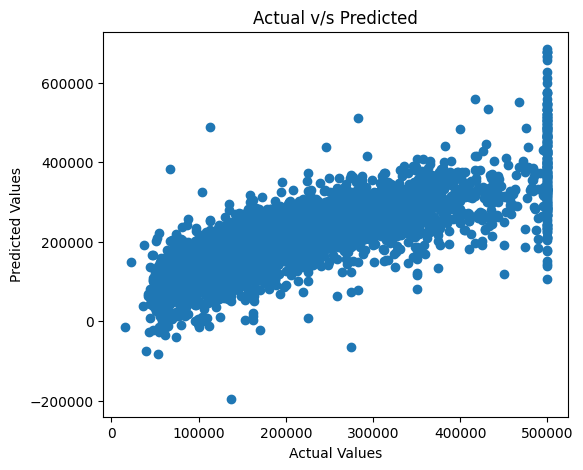

In [38]:
#Actual v/s Predicted
plt.figure(figsize=(6,5))
plt.scatter(y_test,y_test_pred)
plt.title("Actual v/s Predicted")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.show()